In [1]:
import importlib.util
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from peft import PeftModel

ROOT = Path.cwd()
if not (ROOT / "pilot_llm").exists() and (ROOT / "aeroduo" / "pilot_llm").exists():
    ROOT = ROOT / "aeroduo"
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

sys.argv = ["ipykernel_launcher.py"]
plt.rcParams["figure.dpi"] = 140


/storage/project/r-cj124-0/sibidapo3/anxcnda/aeroduo/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_MODEL_PATH = ROOT / "pilot_llm" / "weights" / "Qwen2-VL-2B-Instruct"
PILOT_CKPT_PATH = ROOT / "pilot_llm" / "weights" / "AeroDuo-PilotLLM"
DATASET_JSON = ROOT / "data" / "train_data_sample.json"
SAMPLE_INDEX = 54
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DTYPE = torch.float32
USE_ZERO_FP32_CHECKPOINT = True

BASE_MODEL_PATH, PILOT_CKPT_PATH, DATASET_JSON, SAMPLE_INDEX, DEVICE, MODEL_DTYPE, USE_ZERO_FP32_CHECKPOINT


(PosixPath('/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/weights/Qwen2-VL-2B-Instruct'),
 PosixPath('/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/weights/AeroDuo-PilotLLM'),
 PosixPath('/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/train_data_sample.json'),
 54,
 device(type='cuda'),
 torch.float32,
 True)

In [3]:
def get_project_modules():
    try:
        from pilot_llm.dataset.airsim_dataset import AirSimDataset, collate_fn
        from pilot_llm.models.pilot_llm import PilotLLM
        from pilot_llm.models.processing_qwen2_vl import Qwen2VLProcessor
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Missing project dependency while loading the eval stack. Install the AeroDuo/PilotLLM notebook requirements and rerun this cell. If OpenCV is missing, install `opencv-python`."
        ) from exc
    return AirSimDataset, collate_fn, PilotLLM, Qwen2VLProcessor


def load_zero_fp32_state_dict(checkpoint_path=PILOT_CKPT_PATH):
    zero_to_fp32_path = checkpoint_path / "zero_to_fp32.py"
    spec = importlib.util.spec_from_file_location("aeroduo_zero_to_fp32", zero_to_fp32_path)
    module = importlib.util.module_from_spec(spec)
    try:
        spec.loader.exec_module(module)
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "Unable to import the checkpoint conversion helper. Install the DeepSpeed notebook requirements and rerun this cell."
        ) from exc
    return module.get_fp32_state_dict_from_zero_checkpoint(str(checkpoint_path))


def load_pilot_model(
    base_model_path=BASE_MODEL_PATH,
    checkpoint_path=PILOT_CKPT_PATH,
    device=DEVICE,
    model_dtype=MODEL_DTYPE,
    use_zero_fp32_checkpoint=USE_ZERO_FP32_CHECKPOINT,
):
    _, _, PilotLLM, Qwen2VLProcessor = get_project_modules()
    processor = Qwen2VLProcessor.from_pretrained(str(base_model_path), padding_side="right")
    # model = PilotLLM.from_pretrained(
    #     str(base_model_path),
    #     num_image_token=784,
    #     torch_dtype=torch.float32,
    # )
    # model = PeftModel.from_pretrained(model, str(checkpoint_path))
    model = None
    load_source = "mp_rank_00_model_states.pt"
    # try:
    #     if use_zero_fp32_checkpoint:
    #         state_dict = load_zero_fp32_state_dict(checkpoint_path)
    #         load_result = model.load_state_dict(state_dict, strict=False)
    #         load_source = "zero_to_fp32"
    #     else:
    #         raise RuntimeError("zero_to_fp32 loading disabled")
    # except Exception as exc:
    #     print(f"Falling back to mp_rank_00_model_states.pt because fp32 checkpoint recovery failed: {exc}")
    #     weights = torch.load(
    #         checkpoint_path / "pytorch_model" / "mp_rank_00_model_states.pt",
    #         map_location="cpu",
    #     )
    #     load_result = model.load_state_dict(weights["module"], strict=False)

    # if load_result.missing_keys:
    #     print("Missing keys:", load_result.missing_keys[:20])
    # if load_result.unexpected_keys:
    #     print("Unexpected keys:", load_result.unexpected_keys[:20])

    # model = model.merge_and_unload()
    # model = model.to(device=device, dtype=model_dtype)
    # model.eval()
    return processor, model, load_source


def prepare_batch(dataset_json=DATASET_JSON, sample_index=SAMPLE_INDEX, processor=None):
    AirSimDataset, collate_fn, _, _ = get_project_modules()
    dataset = AirSimDataset([str(dataset_json)])
    sample = dataset[sample_index]
    inputs, kwargs = collate_fn([sample], processor=processor, mission="prob")
    return sample, inputs, kwargs


def move_inputs_to_device(inputs, device=DEVICE):
    return {name: tensor.to(device) for name, tensor in inputs.items()}


In [4]:
_, _, PilotLLM, Qwen2VLProcessor = get_project_modules()
model = PilotLLM.from_pretrained(BASE_MODEL_PATH, num_token=784)
model = PeftModel.from_pretrained(model, PILOT_CKPT_PATH)
weights = torch.load(os.path.join(PILOT_CKPT_PATH, "pytorch_model/mp_rank_00_model_states.pt"))
model.load_state_dict(weights['module'], strict=False)
model = model.to(DEVICE)
model.eval()
processor, _, load_source = load_pilot_model()

`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.31it/s]
Some weights of PilotLLM were not initialized from the model checkpoint at /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/weights/Qwen2-VL-2B-Instruct and are newly initialized: ['depth_head.mlp.0.bias', 'depth_head.mlp.0.weight', 'depth_head.mlp.2.bias', 'depth_head.mlp.2.weight', 'mask_head.mlp.0.bias', 'mask_head.mlp.0.weight', 'mask_head.mlp.2.bias', 'mask_head.mlp.2.weight', 'mask_query']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_481021/3851314895.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data 

In [5]:
warm_up = False
sample, inputs, kwargs = prepare_batch(sample_index=SAMPLE_INDEX, processor=processor)
model_inputs = move_inputs_to_device(inputs)
labels = kwargs["labels"].to(DEVICE)

if not warm_up:
    with torch.no_grad():
        model(**model_inputs, labels=labels, is_inference=True, mission="prob")
    warm_up = True

with torch.no_grad():
    pred_masks = model(**model_inputs, labels=labels, is_inference=True, mission="prob")

dataset has 53137 samples load from file ['/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/train_data_sample.json']


In [6]:
pred_masks.shape

torch.Size([1, 1, 784, 784])

In [7]:
dataset_json=DATASET_JSON
sample_index = 10
AirSimDataset, collate_fn, _, _ = get_project_modules()
dataset = AirSimDataset([str(dataset_json)])
sample = dataset[sample_index]

dataset has 53137 samples load from file ['/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/train_data_sample.json']


In [8]:
import json

import cv2
import numpy as np


def _read_json(path):
    with open(path, "r") as handle:
        return json.load(handle)


def _select_sample_history_times(image_numbers, int_time, video_frame_num):
    available_images = [timestamp for timestamp in image_numbers if timestamp <= int_time]
    if len(available_images) <= video_frame_num or video_frame_num <= 1:
        return available_images[-video_frame_num:]

    indices = [
        round(i * (len(available_images) - 1) / (video_frame_num - 1))
        for i in range(video_frame_num)
    ]
    return [available_images[i] for i in indices]


def prepare_llm_sample_batch(sample, dataset=None, dataset_json=DATASET_JSON):
    if dataset is None:
        AirSimDataset, _, _, _ = get_project_modules()
        dataset = AirSimDataset([str(dataset_json)])

    traj_dir = Path(sample["traj_dir"])
    int_time = int(sample["target_time"] - dataset.target_interval)

    image_dir = traj_dir / "bevcamera"
    depth_dir = traj_dir / "bevcamera_depth"
    log_dir = traj_dir / "log"

    image_numbers = sorted(
        int(Path(filename).stem)
        for filename in os.listdir(image_dir)
        if filename.endswith(".png")
    )
    history_times = _select_sample_history_times(
        image_numbers,
        int_time=int_time,
        video_frame_num=dataset.video_frame_num,
    )
    history_names = [f"{timestamp:06d}" for timestamp in history_times]

    frame_paths = [image_dir / f"{name}.png" for name in history_names]
    depth_paths = [depth_dir / f"{name}.png" for name in history_names]
    log_paths = [log_dir / f"{name}.json" for name in history_names]

    high_uav_history = np.array(
        [_read_json(log_path)["sensors"]["state"]["position"] for log_path in log_paths],
        dtype=np.float32,
    )
    bev_images = np.stack([cv2.imread(str(frame_path)) for frame_path in frame_paths], axis=0)
    bev_depths = np.stack(
        [cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED) for depth_path in depth_paths],
        axis=0,
    )
    point_clouds = dataset.ortho_processor.project_images_to_3d(bev_depths, high_uav_history)

    description = _read_json(traj_dir / "object_description_with_help.json")[0]
    gt_waypoints = _read_json(traj_dir / "gt_waypoints.json")

    if len(gt_waypoints) > len(image_numbers):
        waypoint_indices = [
            round(i * (len(gt_waypoints) - 1) / (len(image_numbers) - 1))
            for i in range(len(image_numbers))
        ]
    else:
        waypoint_indices = list(range(len(gt_waypoints)))

    current_image_index = image_numbers.index(int_time)
    low_uav_location = gt_waypoints[waypoint_indices[current_image_index]]
    high_uav_location = high_uav_history[-1].tolist()

    return {
        "bev_images": [bev_images],
        "bev_depths": [bev_depths],
        "point_clouds": [point_clouds],
        "high_uav_locations": [high_uav_location],
        "low_uav_locations": [low_uav_location],
        "description": [description],
    }


In [9]:
def get_bev_images(sample_batch):
    return sample_batch["bev_images"]


def get_bev_depths(sample_batch):
    return sample_batch["bev_depths"]


def get_point_clouds(sample_batch):
    return sample_batch["point_clouds"]


def get_high_uav_locations(sample_batch):
    return sample_batch["high_uav_locations"]


def get_low_uav_locations(sample_batch):
    return sample_batch["low_uav_locations"]


def get_description(sample_batch):
    return sample_batch["description"]

def preprocess(image, pad_color=(0,0,0)):
    h, w = image.shape[:2]
    img_size=784
    scale = img_size * 1.0 / max(h, w)
    new_h, new_w = h * scale, w * scale
    new_w = int(new_w + 0.5)
    new_h = int(new_h + 0.5)
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    resized_hw = (new_h, new_w)

    pad_h = img_size - new_h
    pad_w = img_size - new_w
    padded_image = cv2.copyMakeBorder(resized_image, 0, pad_h, 0, pad_w,
                                    cv2.BORDER_CONSTANT, value=pad_color)
    return padded_image, resized_hw

In [10]:
sample_batch = prepare_llm_sample_batch(sample, dataset=dataset)

bev_images = get_bev_images(sample_batch)
bev_depths = get_bev_depths(sample_batch)
point_clouds = get_point_clouds(sample_batch)
high_uav_locations = get_high_uav_locations(sample_batch)
low_uav_locations = get_low_uav_locations(sample_batch)
description = get_description(sample_batch)

{
    "bev_images_shape": np.asarray(bev_images[0]).shape,
    "bev_depths_shape": np.asarray(bev_depths[0]).shape,
    "point_clouds_shape": np.asarray(point_clouds[0]).shape,
    "high_uav_locations": high_uav_locations,
    "low_uav_locations": low_uav_locations,
    "description_preview": description[0][:160],
}


{'bev_images_shape': (3, 1024, 1024, 3),
 'bev_depths_shape': (3, 1024, 1024),
 'point_clouds_shape': (3, 1024, 1024, 3),
 'high_uav_locations': [[225.0496063232422,
   -172.90403747558594,
   -29.928035736083984]],
 'low_uav_locations': [[224.18766666666667, -173.42499999999998, -4.998]],
 'description_preview': "Compass north corresponds to the top of the bird's-eye-view image. The target location is 65.61 degrees south by east from the starting point. The description o"}

In [11]:
from pilot_llm.orthography import Orthophoto

ortho_processor = Orthophoto()

history_orthophotos = []
ortho_depths = []
coor_maps = []
resized_record = []
original_shapes = []
for bev_image, bev_depth, point_cloud in zip(bev_images, bev_depths, point_clouds):
    ortho, coor_map, merged_depth = ortho_processor.orthorectify(np.array(bev_image), np.array(point_cloud), np.array(bev_depth))
    original_shapes.append(ortho.shape[:2])
    ortho_pad_resize, resized_hw = preprocess(ortho)
    history_orthophotos.append(ortho_pad_resize)
    ortho_depths.append(merged_depth)
    coor_maps.append(coor_map)
    resized_record.append(resized_hw)

In [12]:
prob_maps = np.array(pred_masks.squeeze(dim=1).cpu())
for i, prob_map in enumerate(prob_maps):
    resized_hw = resized_record[i]
    prob_map = prob_map[:resized_hw[0], :resized_hw[1]]
    origin_shape = original_shapes[i]
    prob_map = cv2.resize(prob_map, (origin_shape[1], origin_shape[0]), interpolation=cv2.INTER_NEAREST)
    depth = ortho_depths[i]
    delta_height = low_uav_locations[i][2] - high_uav_locations[i][2] 
    h, w = prob_map.shape
    prob_map = torch.sigmoid(torch.tensor(prob_map)).flatten()
    prob_map_top_k = torch.topk(prob_map, k=20000)
    new_prob_map = torch.zeros_like(prob_map)
    new_prob_map[prob_map_top_k.indices] = prob_map_top_k.values
    prob_map = new_prob_map.reshape(h, w).cpu().numpy()

    occupancy_map = (depth >= delta_height).astype(np.uint8).squeeze()
    if np.all(prob_map * occupancy_map == 0):
        print(f"Warning: all zero prob_map")
        prob_map = prob_map
    else:
        prob_map = prob_map * occupancy_map

/tmp/ipykernel_481021/1156224488.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_maps = np.array(pred_masks.squeeze(dim=1).cpu())


In [13]:
prob_map.shape

(356, 364)

In [ ]:
# processor, model, load_source = load_pilot_model()
# sample, inputs, kwargs = prepare_batch(sample_index=SAMPLE_INDEX, processor=processor)
# model_inputs = move_inputs_to_device(inputs)
# labels = kwargs["labels"].to(DEVICE)

# with torch.no_grad():
#     _ = model(**model_inputs, labels=labels, is_inference=True, mission="prob")
#     pred_masks = model(**model_inputs, labels=labels, is_inference=True, mission="prob")

# pred_masks = pred_masks.detach().float()
# num_non_finite = int((~torch.isfinite(pred_masks)).sum().item())

# pred_logits = pred_masks[0, 0]
# if num_non_finite:
#     print(f"Warning: pred_masks contains {num_non_finite} non-finite values after loading from {load_source}. Replacing them before visualization.")
#     pred_logits = torch.nan_to_num(pred_logits, nan=0.0, posinf=20.0, neginf=-20.0)

# gt_mask = kwargs["masks_list"][0].squeeze(0).cpu().numpy()
# pred_map = torch.sigmoid(pred_logits).cpu().numpy()
# traj_dir = kwargs["traj_folders"][0]
# pred_time = kwargs["pred_time"][0]

# print(f"load_source: {load_source}")
# print(f"traj_dir: {traj_dir}")
# print(f"pred_time: {pred_time}")
# print(f"pred_masks non-finite count: {num_non_finite}")
# print(f"gt_mask shape: {gt_mask.shape}, pred_map shape: {pred_map.shape}")


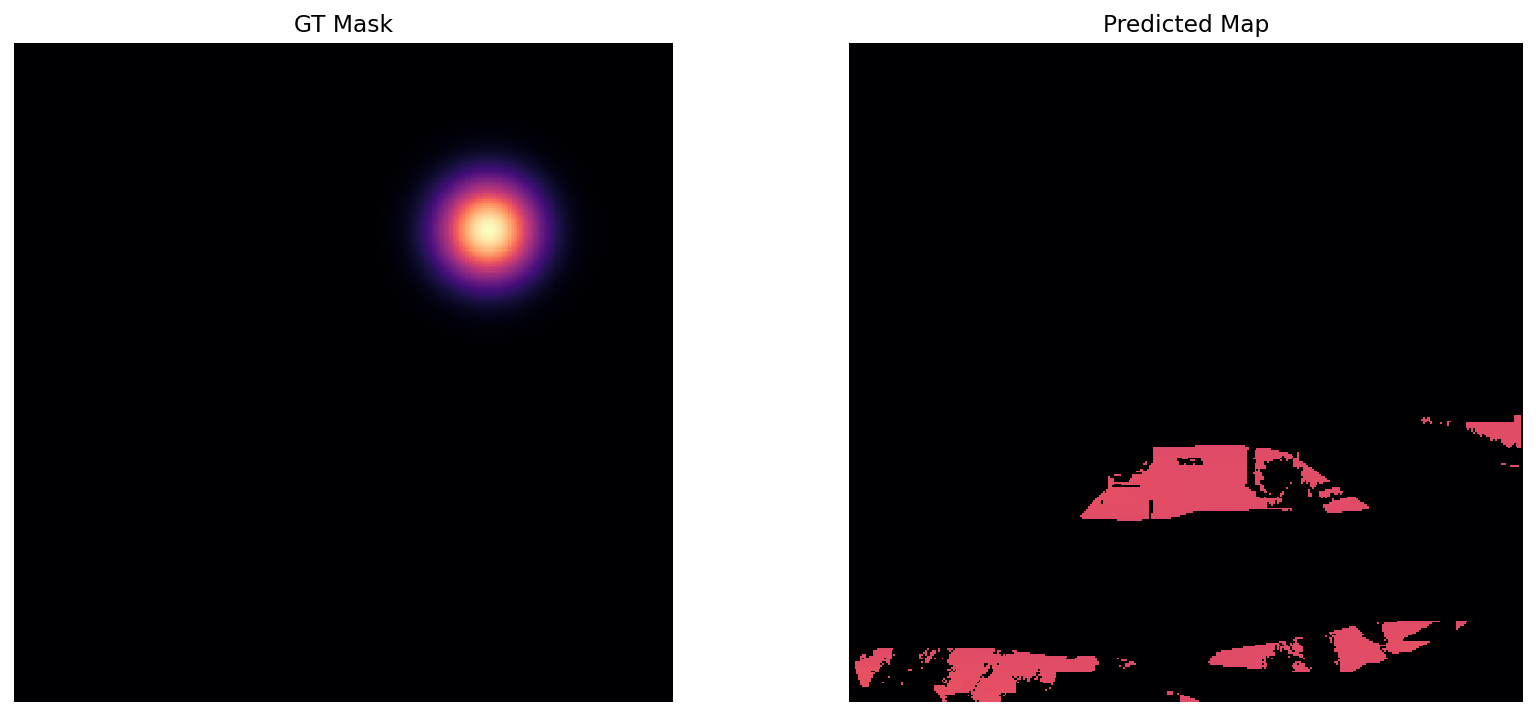

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
#fig.suptitle(f"{Path(traj_dir).name} | target time {pred_time}")
gt_mask = kwargs["masks_list"][0].squeeze(0).cpu().numpy()
axes[0].imshow(gt_mask, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_title("GT Mask")
axes[0].axis("off")

axes[1].imshow(prob_map, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Predicted Map")
axes[1].axis("off")

plt.show()


In [15]:
import gc

model = model.to("cpu")
del model
gc.collect()
torch.cuda.empty_cache()

In [18]:
torch.max(torch.sigmoid(torch.tensor(prob_maps[0])))

tensor(0.6405)

In [19]:
torch.min(torch.sigmoid(torch.tensor(prob_maps[0])))

tensor(0.4505)

In [20]:
torch.sigmoid(torch.tensor(prob_maps[0]))

tensor([[0.4884, 0.4884, 0.4884,  ..., 0.5251, 0.5251, 0.5251],
        [0.4884, 0.4884, 0.4884,  ..., 0.5251, 0.5251, 0.5251],
        [0.4884, 0.4884, 0.4884,  ..., 0.5251, 0.5251, 0.5251],
        ...,
        [0.6240, 0.6240, 0.6240,  ..., 0.6017, 0.6017, 0.6017],
        [0.6240, 0.6240, 0.6240,  ..., 0.6017, 0.6017, 0.6017],
        [0.6240, 0.6240, 0.6240,  ..., 0.6017, 0.6017, 0.6017]])

In [21]:
prob_maps

array([[[-0.04653057, -0.04653057, -0.04653057, ...,  0.10030147,
          0.10030147,  0.10030147],
        [-0.04653057, -0.04653057, -0.04653057, ...,  0.10030147,
          0.10030147,  0.10030147],
        [-0.04653057, -0.04653057, -0.04653057, ...,  0.10030147,
          0.10030147,  0.10030147],
        ...,
        [ 0.50646096,  0.50646096,  0.50646096, ...,  0.41259882,
          0.41259882,  0.41259882],
        [ 0.50646096,  0.50646096,  0.50646096, ...,  0.41259882,
          0.41259882,  0.41259882],
        [ 0.50646096,  0.50646096,  0.50646096, ...,  0.41259882,
          0.41259882,  0.41259882]]], shape=(1, 784, 784), dtype=float32)

In [ ]:
from pilot_llm.models_smolvlm.pilot_llm_smolvlm import PilotLLMSmolVLM
from transformers import AutoProcessor

ROOT = Path.cwd()
if not (ROOT / "pilot_llm").exists() and (ROOT / "aeroduo" / "pilot_llm").exists():
    ROOT = ROOT / "aeroduo"
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    
SMOLVLM_CACHE_PATH = ROOT / "pilot_llm" / "weights" / "huggingface" / "models--HuggingFaceTB--SmolVLM2-2.2B-Instruct"
SMOLVLM_BASE_MODEL_PATH = SMOLVLM_CACHE_PATH / "snapshots" / (SMOLVLM_CACHE_PATH / "refs" / "main").read_text().strip()
SMOLVLM_CKPT_PATH = ROOT / "pilot_llm" / "model_output" / "smolvlm_main" / "checkpoint-400"

model_s = PilotLLMSmolVLM.from_pretrained(
    str(SMOLVLM_BASE_MODEL_PATH),
    num_image_token=2048,
    torch_dtype=MODEL_DTYPE,
)
model_s = PeftModel.from_pretrained(model_s, str(SMOLVLM_CKPT_PATH))
weights_s = torch.load(SMOLVLM_CKPT_PATH / "pytorch_model" / "mp_rank_00_model_states.pt", map_location="cpu")
model_s.load_state_dict(weights_s["module"], strict=False)
model_s = model_s.to(DEVICE)
model_s.eval()

processor_s = AutoProcessor.from_pretrained(SMOLVLM_BASE_MODEL_PATH,
                                              cache_dir=SMOLVLM_CACHE_PATH,
                                              padding_side="right")
sample, inputs, kwargs = prepare_batch(sample_index=50, processor=processor_s)

model_inputs = move_inputs_to_device(inputs)
labels = kwargs["labels"].to(DEVICE)

warm_up = False
if not warm_up:
    with torch.no_grad():
        model_s(**model_inputs, labels=labels, is_inference=True, mission="prob")
    warm_up = True

with torch.no_grad():
    pred_masks = model_s(**model_inputs, labels=labels, is_inference=True, mission="prob")

In [29]:
sample_batch = prepare_llm_sample_batch(sample, dataset=dataset)

bev_images = get_bev_images(sample_batch)
bev_depths = get_bev_depths(sample_batch)
point_clouds = get_point_clouds(sample_batch)
high_uav_locations = get_high_uav_locations(sample_batch)
low_uav_locations = get_low_uav_locations(sample_batch)
description = get_description(sample_batch)

{
    "bev_images_shape": np.asarray(bev_images[0]).shape,
    "bev_depths_shape": np.asarray(bev_depths[0]).shape,
    "point_clouds_shape": np.asarray(point_clouds[0]).shape,
    "high_uav_locations": high_uav_locations,
    "low_uav_locations": low_uav_locations,
    "description_preview": description[0][:160],
}

from pilot_llm.orthography import Orthophoto

ortho_processor = Orthophoto()

history_orthophotos = []
ortho_depths = []
coor_maps = []
resized_record = []
original_shapes = []
for bev_image, bev_depth, point_cloud in zip(bev_images, bev_depths, point_clouds):
    ortho, coor_map, merged_depth = ortho_processor.orthorectify(np.array(bev_image), np.array(point_cloud), np.array(bev_depth))
    original_shapes.append(ortho.shape[:2])
    ortho_pad_resize, resized_hw = preprocess(ortho)
    history_orthophotos.append(ortho_pad_resize)
    ortho_depths.append(merged_depth)
    coor_maps.append(coor_map)
    resized_record.append(resized_hw)

prob_maps = np.array(pred_masks_s.squeeze(dim=1).cpu())
for i, prob_map in enumerate(prob_maps):
    resized_hw = resized_record[i]
    prob_map = prob_map[:resized_hw[0], :resized_hw[1]]
    origin_shape = original_shapes[i]
    prob_map = cv2.resize(prob_map, (origin_shape[1], origin_shape[0]), interpolation=cv2.INTER_NEAREST)
    depth = ortho_depths[i]
    delta_height = low_uav_locations[i][2] - high_uav_locations[i][2] 
    h, w = prob_map.shape
    prob_map = torch.sigmoid(torch.tensor(prob_map)).flatten()
    prob_map_top_k = torch.topk(prob_map, k=20000)
    new_prob_map = torch.zeros_like(prob_map)
    new_prob_map[prob_map_top_k.indices] = prob_map_top_k.values
    prob_map = new_prob_map.reshape(h, w).cpu().numpy()

    occupancy_map = (depth >= delta_height).astype(np.uint8).squeeze()
    if np.all(prob_map * occupancy_map == 0):
        print(f"Warning: all zero prob_map")
        prob_map = prob_map
    else:
        prob_map = prob_map * occupancy_map

/tmp/ipykernel_481021/1814550266.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  prob_maps = np.array(pred_masks_s.squeeze(dim=1).cpu())


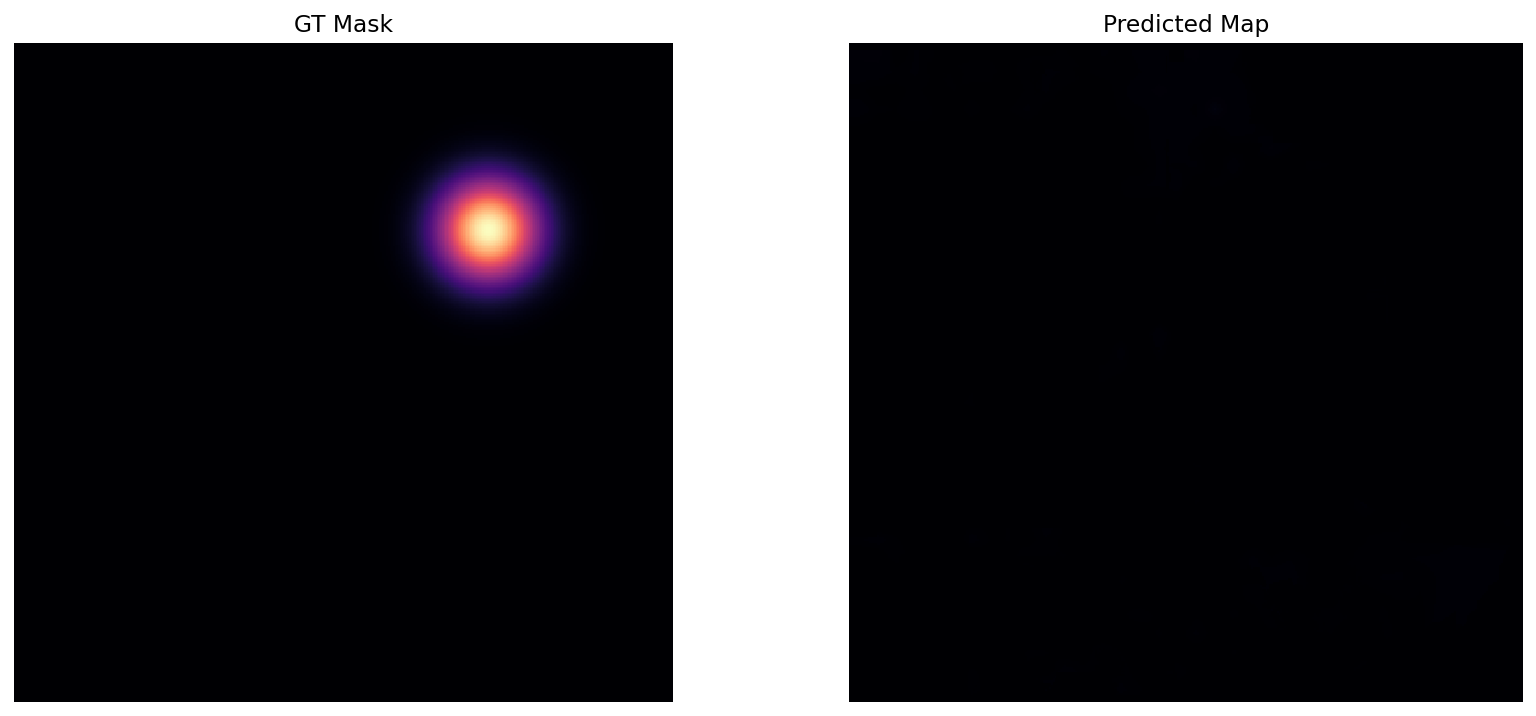

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
#fig.suptitle(f"{Path(traj_dir).name} | target time {pred_time}")
gt_mask = kwargs_s["masks_list"][0].squeeze(0).cpu().numpy()
axes[0].imshow(gt_mask, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_title("GT Mask")
axes[0].axis("off")

axes[1].imshow(prob_map, cmap="magma", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Predicted Map")
axes[1].axis("off")

plt.show()


In [23]:
def get_smolvlm_modules():
    from transformers import AutoProcessor
    from pilot_llm.dataset_smolvlm.airsim_dataset import AirSimDataset as AirSimDatasetSmol, collate_fn as collate_fn_smol
    from pilot_llm.models_smolvlm.pilot_llm_smolvlm import PilotLLMSmolVLM
    return AirSimDatasetSmol, collate_fn_smol, PilotLLMSmolVLM, AutoProcessor


def get_smolvlm_paths(root=ROOT):
    smolvlm_cache_path = root / "pilot_llm" / "weights" / "huggingface" / "models--HuggingFaceTB--SmolVLM2-2.2B-Instruct"
    smolvlm_base_model_path = smolvlm_cache_path / "snapshots" / (smolvlm_cache_path / "refs" / "main").read_text().strip()
    smolvlm_ckpt_path = root / "pilot_llm" / "model_output" / "smolvlm_main" / "checkpoint-400"
    return smolvlm_base_model_path, smolvlm_ckpt_path, smolvlm_cache_path


def load_pilot_smolvlm_model(device=DEVICE, model_dtype=MODEL_DTYPE):
    _, _, PilotLLMSmolVLM, AutoProcessor = get_smolvlm_modules()
    smolvlm_base_model_path, smolvlm_ckpt_path, smolvlm_cache_path = get_smolvlm_paths()

    processor_s = AutoProcessor.from_pretrained(
        str(smolvlm_base_model_path),
        cache_dir=str(smolvlm_cache_path),
        padding_side="right",
    )
    model_s = PilotLLMSmolVLM.from_pretrained(
        str(smolvlm_base_model_path),
        num_image_token=2048,
        torch_dtype=model_dtype,
    )
    model_s = PeftModel.from_pretrained(model_s, str(smolvlm_ckpt_path))
    weights_s = torch.load(smolvlm_ckpt_path / "pytorch_model" / "mp_rank_00_model_states.pt", map_location="cpu")
    model_s.load_state_dict(weights_s["module"], strict=False)
    model_s = model_s.to(device)
    model_s.eval()
    return processor_s, model_s


def prepare_batch_smol(dataset_json=DATASET_JSON, sample_index=SAMPLE_INDEX, processor=None):
    AirSimDatasetSmol, collate_fn_smol, _, _ = get_smolvlm_modules()
    dataset_s = AirSimDatasetSmol([str(dataset_json)])
    sample_s = dataset_s[sample_index]
    inputs_s, kwargs_s = collate_fn_smol([sample_s], processor=processor, mission="prob")
    return sample_s, inputs_s, kwargs_s


def move_model_kwargs_to_device(kwargs, device=DEVICE):
    model_kwargs = {"labels": kwargs["labels"].to(device)}
    if "masks_list" in kwargs:
        model_kwargs["masks_list"] = [mask.to(device) for mask in kwargs["masks_list"]]
    if "mission" in kwargs:
        model_kwargs["mission"] = kwargs["mission"]
    return model_kwargs


In [24]:
processor_s, model_s = load_pilot_smolvlm_model()
sample_s, inputs_s, kwargs_s = prepare_batch_smol(sample_index=SAMPLE_INDEX, processor=processor_s)

model_inputs_s = move_inputs_to_device(inputs_s)
model_kwargs_s = move_model_kwargs_to_device(kwargs_s)

base_model_s = model_s.get_base_model() if hasattr(model_s, "get_base_model") else model_s
image_token_id_s = base_model_s.config.image_token_id
special_mask_s = (model_inputs_s["input_ids"] == image_token_id_s) & (model_kwargs_s["labels"] == image_token_id_s)

{
    "sample_traj_dir": kwargs_s["traj_folders"][0],
    "pred_time": kwargs_s["pred_time"][0],
    "assistant_image_tokens": special_mask_s.sum(dim=1).tolist(),
    "input_keys": sorted(model_inputs_s.keys()),
}


You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 19.99it/s]
Some weights of PilotLLMSmolVLM were not initialized from the model checkpoint at /storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/pilot_llm/weights/huggingface/models--HuggingFaceTB--SmolVLM2-2.2B-Instruct/snapshots/482adb537c021c86670beed01cd58990d01e72e4 and are newly initialized: ['depth_head.mlp.0.bias', 'depth_head.mlp.0.weight', 'depth_head.mlp.2.bias', 'depth_head.mlp.2.weight', 'mask_head.mlp.0.bias', 'mask_head.mlp.0.weight', 'mask_head.mlp.2.bias', 'mask_head.mlp.2.weight', 'mask_query']
You should probably TRAIN this model on a down-stream task to be able to use it for predi

dataset has 53137 samples load from file ['/storage/project/r-cj124-0/sibidapo3/8750/aeroduo_ws/aeroduo/data/train_data_sample.json']


{'sample_traj_dir': 'data/Hal-13k/Carla_Town04/6fe63f8c-99a1-4469-9957-586a9eb44994',
 'pred_time': 45,
 'assistant_image_tokens': [1377],
 'input_keys': ['attention_mask',
  'input_ids',
  'pixel_attention_mask',
  'pixel_values']}

In [25]:
warm_up_s = False

if not warm_up_s:
    with torch.no_grad():
        _ = model_s(**model_inputs_s, **model_kwargs_s, is_inference=True)
    warm_up_s = True

with torch.no_grad():
    pred_masks_s = model_s(**model_inputs_s, **model_kwargs_s, is_inference=True)

pred_masks_s.shape


torch.Size([1, 1, 784, 784])

In [31]:
pred_masks_s

tensor([[[[-4.3073, -4.3073, -4.3073,  ..., -5.2449, -5.2449, -5.2449],
          [-4.3073, -4.3073, -4.3073,  ..., -5.2449, -5.2449, -5.2449],
          [-4.3073, -4.3073, -4.3073,  ..., -5.2449, -5.2449, -5.2449],
          ...,
          [-5.4798, -5.4798, -5.4798,  ..., -5.5417, -5.5417, -5.5417],
          [-5.4798, -5.4798, -5.4798,  ..., -5.5417, -5.5417, -5.5417],
          [-5.4798, -5.4798, -5.4798,  ..., -5.5417, -5.5417, -5.5417]]]],
       device='cuda:0')

In [32]:
prob_maps

array([[[-4.3073244, -4.3073244, -4.3073244, ..., -5.2448564,
         -5.2448564, -5.2448564],
        [-4.3073244, -4.3073244, -4.3073244, ..., -5.2448564,
         -5.2448564, -5.2448564],
        [-4.3073244, -4.3073244, -4.3073244, ..., -5.2448564,
         -5.2448564, -5.2448564],
        ...,
        [-5.4798126, -5.4798126, -5.4798126, ..., -5.5416746,
         -5.5416746, -5.5416746],
        [-5.4798126, -5.4798126, -5.4798126, ..., -5.5416746,
         -5.5416746, -5.5416746],
        [-5.4798126, -5.4798126, -5.4798126, ..., -5.5416746,
         -5.5416746, -5.5416746]]], shape=(1, 784, 784), dtype=float32)

In [33]:
torch.min(torch.sigmoid(torch.tensor(prob_maps[0])))

tensor(0.0031)

In [34]:
torch.max(torch.sigmoid(torch.tensor(prob_maps[0])))

tensor(0.0246)

In [35]:
torch.sigmoid(torch.tensor(prob_maps[0]))

tensor([[0.0133, 0.0133, 0.0133,  ..., 0.0052, 0.0052, 0.0052],
        [0.0133, 0.0133, 0.0133,  ..., 0.0052, 0.0052, 0.0052],
        [0.0133, 0.0133, 0.0133,  ..., 0.0052, 0.0052, 0.0052],
        ...,
        [0.0042, 0.0042, 0.0042,  ..., 0.0039, 0.0039, 0.0039],
        [0.0042, 0.0042, 0.0042,  ..., 0.0039, 0.0039, 0.0039],
        [0.0042, 0.0042, 0.0042,  ..., 0.0039, 0.0039, 0.0039]])